In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS
from tqdm import tqdm

import os
import sys
current_dir = os.path.abspath('')
grandparent_dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

from util import *
from model.KAN import Model


if not os.path.exists('results'):
    os.makedirs('results')

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = 'cuda'

In [3]:
res, b_left, b_right, b_upper, b_lower = get_data([-1,1], [0,1], 51, 51)
res_test, b_left_test, _, _, _ = get_data([-1,1], [0,1], 256, 201)

res = torch.tensor(res, dtype=torch.float32, requires_grad=True).to(device)
b_left = torch.tensor(b_left, dtype=torch.float32, requires_grad=True).to(device)
b_right = torch.tensor(b_right, dtype=torch.float32, requires_grad=True).to(device)
b_upper = torch.tensor(b_upper, dtype=torch.float32, requires_grad=True).to(device)
b_lower = torch.tensor(b_lower, dtype=torch.float32, requires_grad=True).to(device)

x_res, t_res = res[:,0:1], res[:,1:2]
x_left, t_left = b_left[:,0:1], b_left[:,1:2]
x_right, t_right = b_right[:,0:1], b_right[:,1:2]
x_upper, t_upper = b_upper[:,0:1], b_upper[:,1:2]
x_lower, t_lower = b_lower[:,0:1], b_lower[:,1:2]

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)

In [4]:
from scipy.io import loadmat

mat = loadmat('./kdv_ref.mat')
x_data = mat['X_grid'].flatten()[:,None]
t_data = mat['T_grid'].flatten()[:,None]
u_data = mat['u_exact'].flatten()[:,None]

x_data = torch.tensor(x_data, dtype=torch.float32, requires_grad=True).to(device)
t_data = torch.tensor(t_data, dtype=torch.float32, requires_grad=True).to(device)
u_data = torch.tensor(u_data, dtype=torch.float32, requires_grad=True).to(device)

In [5]:
model = Model(width=[2, 5, 5, 1], grid=5, k=3, grid_eps=1.0, noise_scale_base=0.25, device=device).to(device)
# model.apply(init_weights)

optim = torch.optim.LBFGS(model.parameters(), line_search_fn="strong_wolfe")
print(model)
print(get_n_params(model))

Model(
  (biases): ModuleList(
    (0-1): 2 x Linear(in_features=5, out_features=1, bias=False)
    (2): Linear(in_features=1, out_features=1, bias=False)
  )
  (act_fun): ModuleList(
    (0-2): 3 x KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
  (symbolic_fun): ModuleList(
    (0-2): 3 x Symbolic_KANLayer()
  )
)
891


In [6]:
relative_l2_threshold = 0.1
monitor_reference = u_data.detach().cpu().numpy().reshape(-1, 1)

def get_monitor_prediction():
    with torch.no_grad():
        prediction = model(x_data, t_data)[:, 0:1]
    return prediction.reshape(-1, 1).cpu().numpy()

convergence_tracker = RelativeL2ConvergenceTracker(
    monitor_reference,
    relative_l2_threshold,
)
convergence_tracker.record(0.0, get_monitor_prediction())


1.029233357212829

In [7]:
time_recorder = ModelTimeRecorder(device)
loss_track = []

for i in tqdm(range(500)):
    def closure():
        pred_res = model(x_res, t_res)
        pred_upper = model(x_upper, t_upper)
        pred_lower = model(x_lower, t_lower)

        u_t = torch.autograd.grad(pred_res, t_res, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]
        u_x = torch.autograd.grad(pred_res, x_res, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_res, grad_outputs=torch.ones_like(u_x), retain_graph=True, create_graph=True)[0]
        u_xxx = torch.autograd.grad(u_xx, x_res, grad_outputs=torch.ones_like(u_xx), retain_graph=True, create_graph=True)[0]

        loss_res = torch.mean((u_t + pred_res * u_x + 0.0025 * u_xxx) ** 2)
        loss_bc = torch.mean((pred_upper - pred_lower) ** 2)

        u_data_pred = model(x_data, t_data)
        loss_data = torch.mean((u_data_pred - u_data) ** 2)

        loss_track.append([loss_res.item(), loss_bc.item(), loss_data.item()])

        loss = loss_res + loss_bc + loss_data

        optim.zero_grad()
        loss.backward()
        return loss

    with time_recorder.record_training():
        optim.step(closure)

    convergence_tracker.record(
        time_recorder.training_time,
        get_monitor_prediction(),
    )

100%|██████████| 500/500 [32:42<00:00,  3.93s/it]


In [8]:
np.save('./results/kdv_loss_kan.npy', loss_track)
torch.save(model.state_dict(), './results/kdv_kan.pt')

print('Loss Res: {:4f}, Loss_BC: {:4f}, Loss_Data: {:4f}'.format(loss_track[-1][0], loss_track[-1][1], loss_track[-1][2]))
print('Train Loss: {:4f}'.format(np.sum(loss_track[-1])))

print('Training Time: {:.2f} s'.format(time_recorder.training_time))

np.save(
    './results/kdv_relative_l2_error_vs_training_time_kan.npy',
    convergence_tracker.as_array(),
)
if convergence_tracker.first_threshold_time is None:
    print('Relative L2 threshold {:.3f} was not reached.'.format(relative_l2_threshold))
else:
    print(
        'Relative L2 threshold {:.3f} first reached at {:.6f} s'.format(
            relative_l2_threshold,
            convergence_tracker.first_threshold_time,
        )
    )


Loss Res: 0.039922, Loss_BC: 0.000909, Loss_Data: 0.224832
Train Loss: 0.265663
Training Time: 1949.10 s
Relative L2 threshold 0.100 was not reached.


Inference Time: 0.018389 s
relative L1 error: 0.615765
relative L2 error: 0.670571


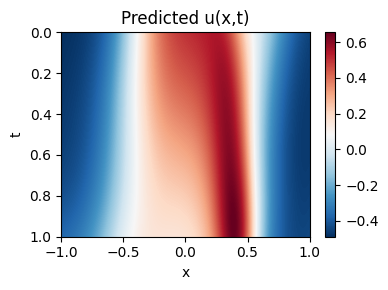

In [9]:
res_test = np.column_stack([
    mat["X_grid"].ravel(),
    mat["T_grid"].ravel(),
])

res_test = torch.tensor(res_test, dtype=torch.float32, requires_grad=True).to(device)
x_test, t_test = res_test[:,0:1], res_test[:,1:2]

with time_recorder.record_inference():
    with torch.no_grad():
        pred = model(x_test, t_test)[:,0:1]
        pred = pred.cpu().detach().numpy()
print('Inference Time: {:.6f} s'.format(time_recorder.inference_time))

pred = pred.reshape(201,256)


u = mat['u_exact']

rl1 = np.sum(np.abs(u-pred)) / np.sum(np.abs(u))
rl2 = np.sqrt(np.sum((u-pred)**2) / np.sum(u**2))

print('relative L1 error: {:4f}'.format(rl1))
print('relative L2 error: {:4f}'.format(rl2))

plt.figure(figsize=(4,3))
plt.imshow(pred, extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/kdv_kan_pred.png')
plt.show()

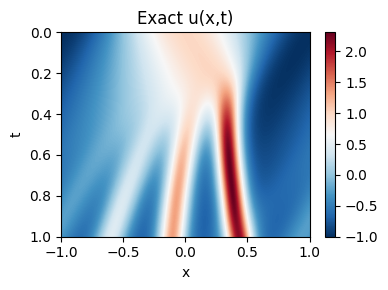

In [10]:
plt.figure(figsize=(4,3))
plt.imshow(u, extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Exact u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/kdv_exact.png')
plt.show()

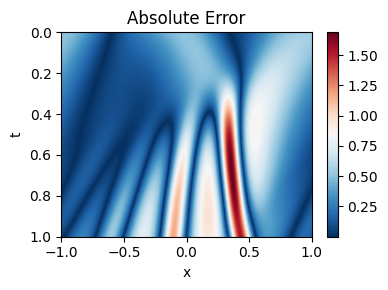

In [11]:
plt.figure(figsize=(4,3))
plt.imshow(np.abs(pred - u), extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/kdv_kan_error.png')
plt.show()

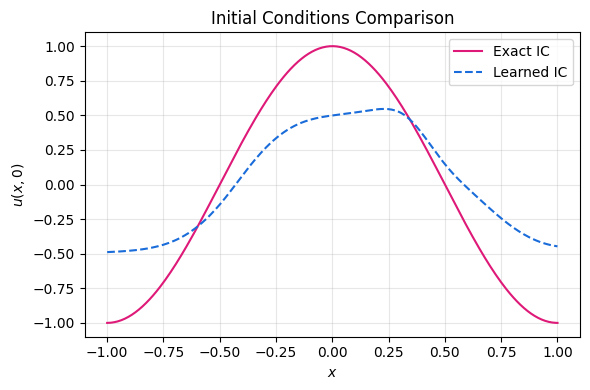

In [12]:
x0_ini = b_left_test[:,0:1]
t0_ini = b_left_test[:,1:2]
u0_ini = np.cos(np.pi * x0_ini)


with torch.no_grad():
    u0_inverse = model(
        torch.tensor(x0_ini, dtype=torch.float32, requires_grad=True).to(device),
        torch.tensor(t0_ini, dtype=torch.float32, requires_grad=True).to(device)
        )
    u0_inverse = u0_inverse.cpu().detach().numpy()
np.save('./results/kdv_u0_inverse_kan.npy', u0_inverse)

plt.figure(figsize=(6,4))
plt.plot(x0_ini, u0_ini, label='Exact IC', color="#de1978")
plt.plot(x0_ini, u0_inverse, label='Learned IC', color="#196cd9", linestyle='--')

plt.xlabel('$x$')
plt.ylabel('$u(x,0)$')
plt.title('Initial Conditions Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./results/kdv_kan_ini.png')
plt.show()

In [13]:

rel_error_ini_l1 = np.linalg.norm(u0_ini - u0_inverse, 1) / np.linalg.norm(u0_ini, 1)
rel_error_ini_l2 = np.linalg.norm(u0_ini - u0_inverse, 2) / np.linalg.norm(u0_ini, 2)
print('Relative L1 Error of Initial Condition: {:4f}'.format(rel_error_ini_l1))
print('Relative L2 Error of Initial Condition: {:4f}'.format(rel_error_ini_l2))



Relative L1 Error of Initial Condition: 0.502667
Relative L2 Error of Initial Condition: 0.510747
